<a href="https://www.kaggle.com/code/kadapagle/peningkatan-kualitas-citra-medis?scriptVersionId=350790665" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

# Pendahuluan 
## A. Identitas
| Nama | NPM | 
| -------- | -------- | 
| M Daffa Arrafi| 24081010035 | 
| Eagan Rainmahasin Alma'qushai| 24081010139 | 
| Daffa Najwan Fadhilah| 24081010172 | 

## B. Laporan
Laporan dan penjelasan terperinci untuk notebook ini dapat diakses melalui tautan berikut: <br>
<img src="https://img.icons8.com/fluency/48/google-docs--v1.png" width="20" height="20" style="vertical-align: middle;"> 
[Document](https://docs.google.com/document/d/1gE4YMEY3KzuJVmRmdh1Xr6TahGEmMtwKv0POYSLculg/edit?usp=sharing) <br>
<img src="https://img.icons8.com/color/48/microsoft-powerpoint-2019--v1.png" width="20" height="20" style="vertical-align: middle;"> [Power Point](google.com) 

## C. Datasets
Dataset diambil dari Kaggle dan bersumber dari beberapa citra medis dari beberapa modalitas. Berikut rincian dataset:<br>
**1. Osteoarthritis** <br>
Osteoarthritis adalah penyakit sendi akibat rusaknya tulang rawan pelindung ujung tulang. Dataset berasal dari citra X-ray.<br>
**2. Chest** <br>
Dataset ini berisi beragam chest x-ray dengan beragam diagnosa dari 30,805 pasien unik<br>
**3. Batu ginjal** <br>
Dataset ini didapat dari hasil USG dan didapat dari beberapa rumah sakit berasal dari Samsung ultrasound machines<br>
**4. Tumor otak** <br>
Tumor otal merupakan penyakit akibat pertumbuhan sel otak tidak terkendali. Dataset ini merupakan kumpulan dari tiga dataset lain dan diambil menggunakan MRI lalu dikategorikan dalam empat kelas<br>
**5. Tumor ginjal** <br>
Dataset ini diambil dari github di bawah lisensi MIT, sementara dataset asli berasal dari kompetisi dan berlisensi CC BY-NC-SA. Dataset ini memanfaatkan modalitas Citra 

# Mengambil Sampel Data

In [1]:
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

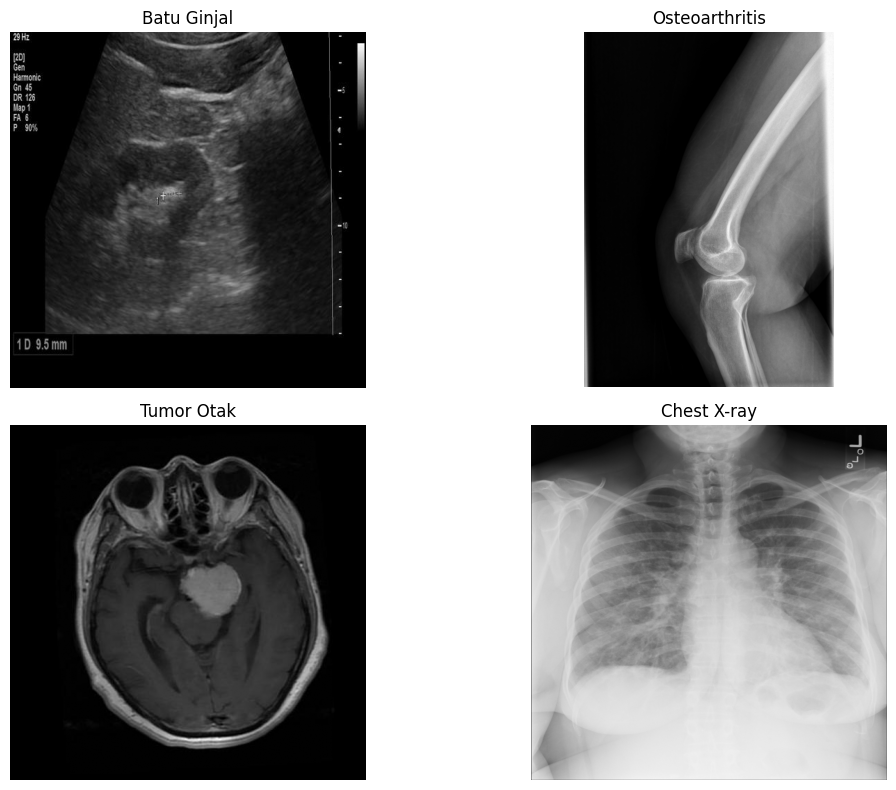

In [2]:
batu_ginjal = cv2.imread('/kaggle/input/datasets/imtkaggleteam/kidney-stone-classification-and-object-detection/stone/Stone_1.JPG', cv2.IMREAD_GRAYSCALE)
osteoarthritis = cv2.imread('/kaggle/input/datasets/dhruvacube/osteoarthritis/withoutKLGrade/withoutKLGrade/patient/014d8da596bf50d1.jpg', cv2.IMREAD_GRAYSCALE)
tumor_otak = cv2.imread('/kaggle/input/datasets/masoudnickparvar/brain-tumor-mri-dataset/Training/meningioma/Tr-aug-me_1.jpg', cv2.IMREAD_GRAYSCALE)
chest = cv2.imread('/kaggle/input/datasets/nih-chest-xrays/sample/sample/sample/images/00000154_001.png', cv2.IMREAD_GRAYSCALE)

gambar = [
    batu_ginjal,
    osteoarthritis,
    tumor_otak,
    chest
]

judul = [
    'Batu Ginjal',
    'Osteoarthritis',
    'Tumor Otak',
    'Chest X-ray'
]

plt.figure(figsize=(12, 8))

for i in range(len(gambar)):
    plt.subplot(2, 2, i + 1)

    plt.imshow(gambar[i], cmap='gray')

    plt.title(judul[i])
    plt.axis('off')

plt.tight_layout()
plt.show()

# Histogram Equlization

# (CLAHE) Contras Limited Adaptive Histogram Equalization 

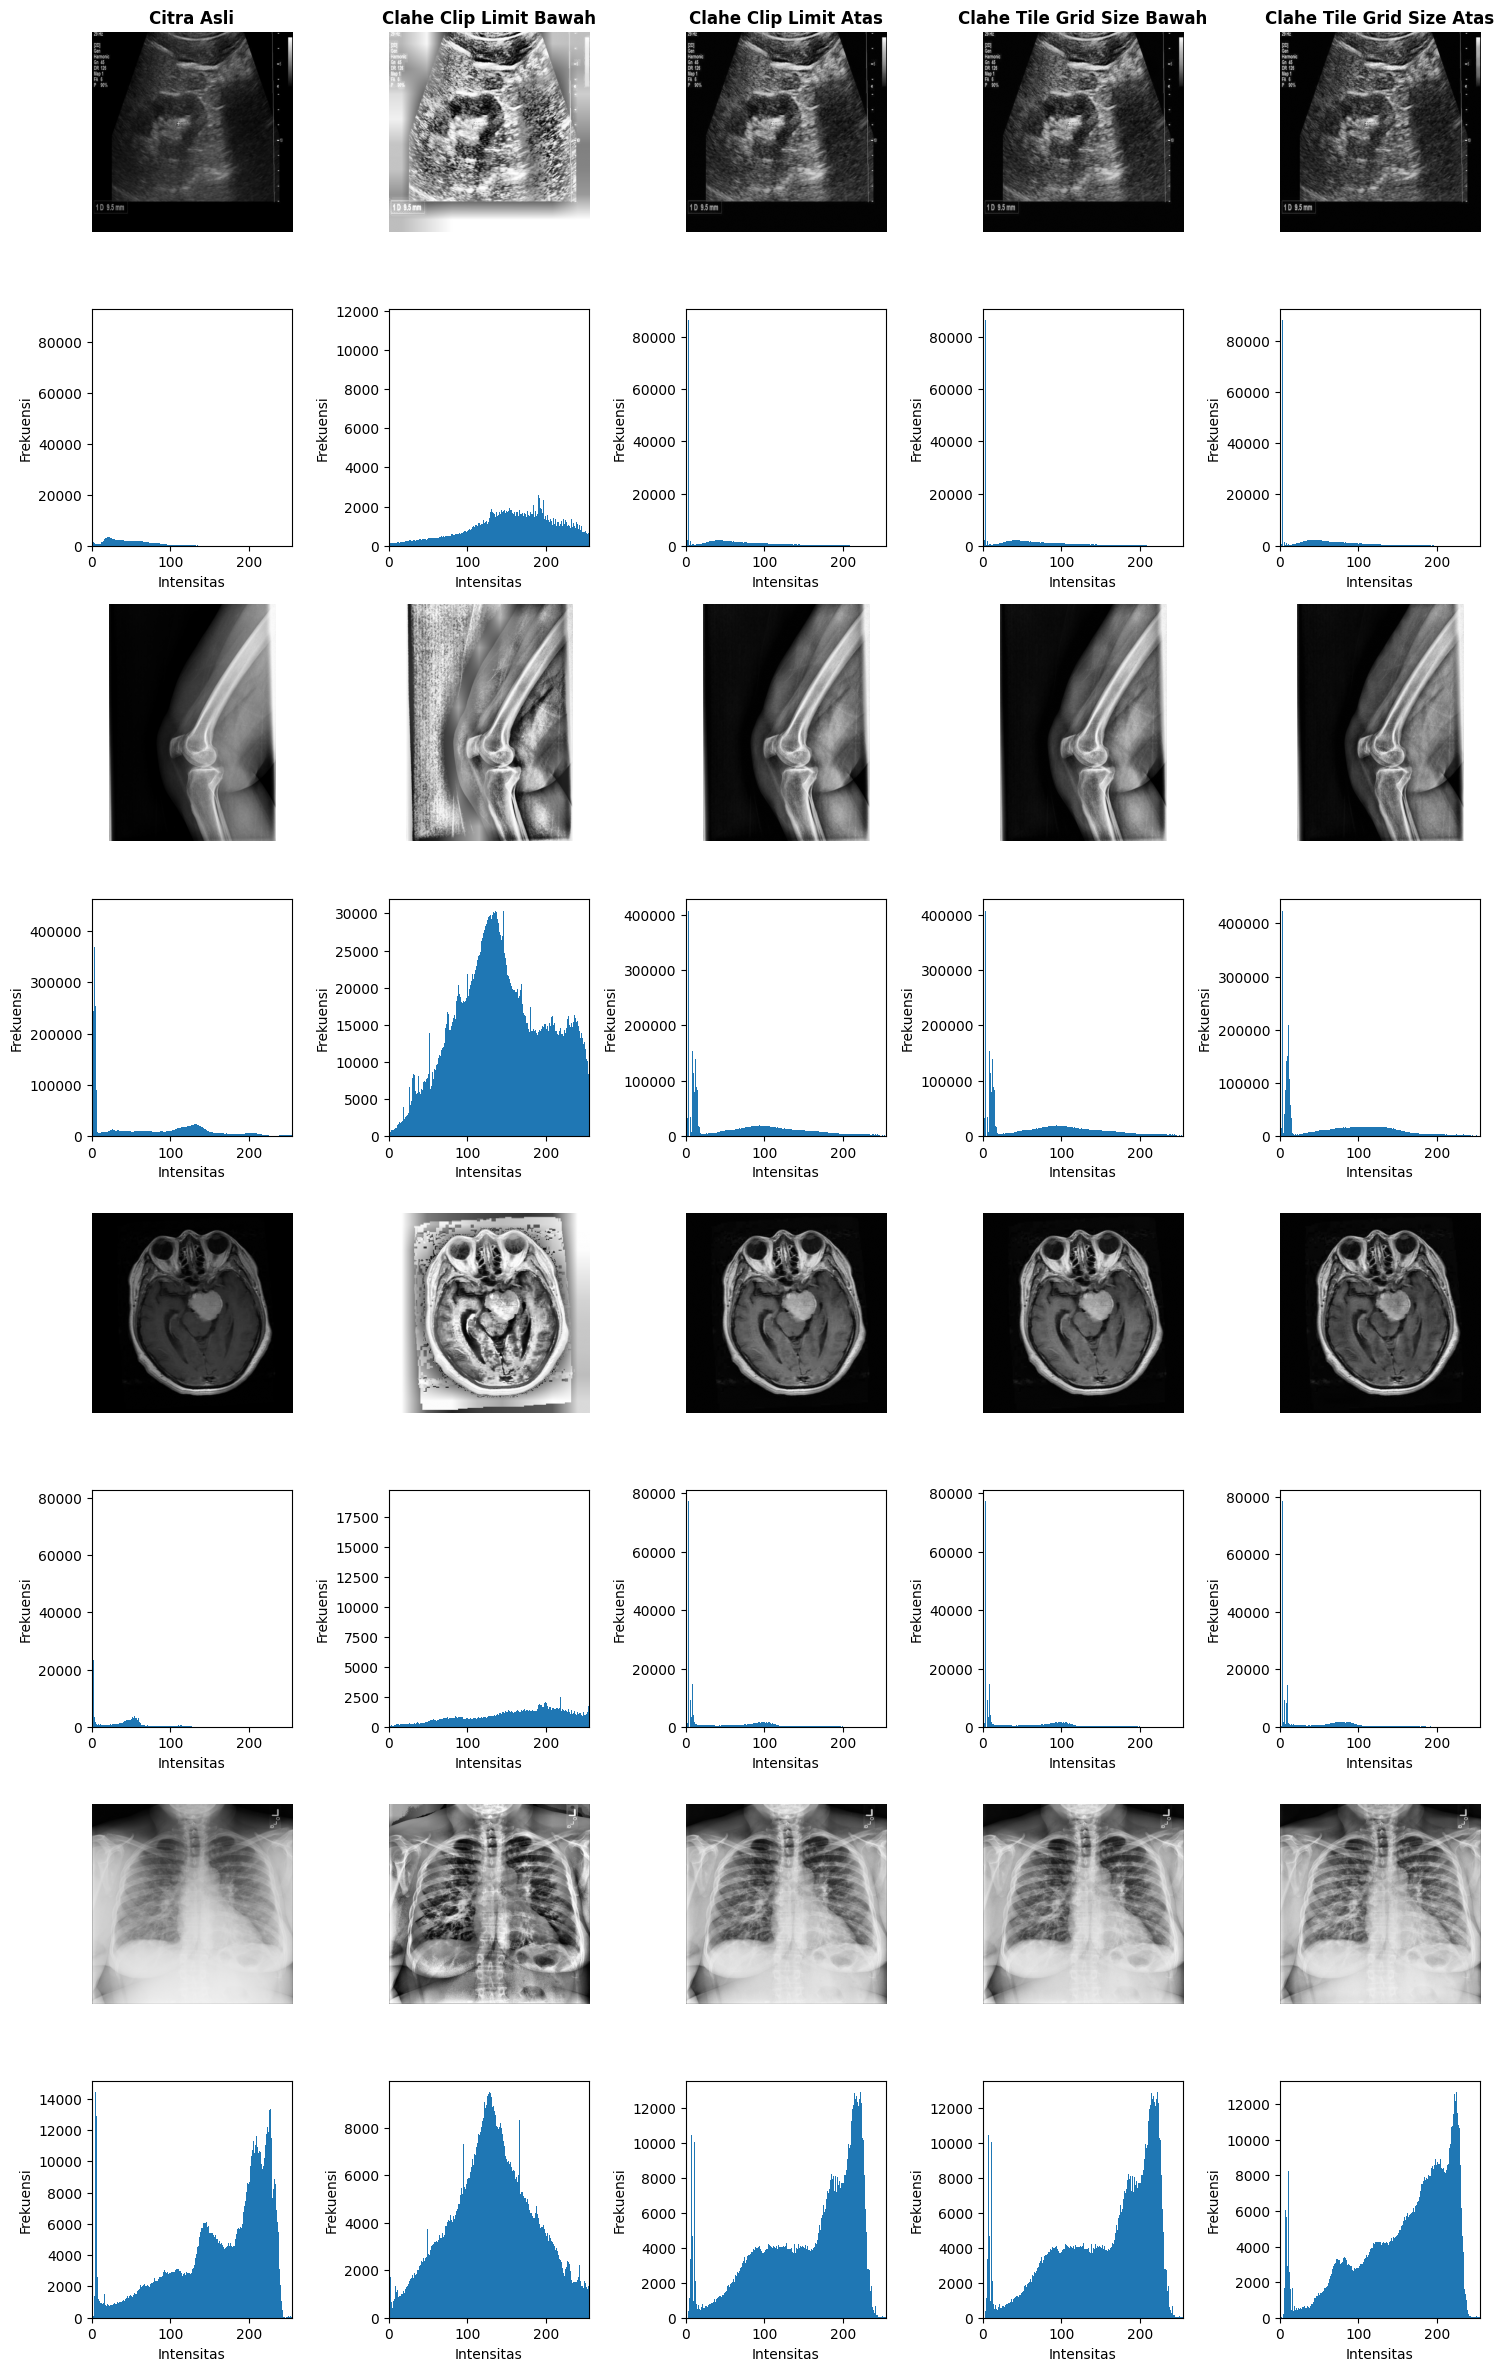

In [3]:
claheCLAI = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
claheCLBI = cv2.createCLAHE(clipLimit=0, tileGridSize=(8, 8))
claheTGSBI = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
claheTGSAI = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(20, 20))
    
claheCLA = []
claheCLB = []
claheTGSB = []
claheTGSA = []
    
for img in gambar:
    claheCLA.append(claheCLAI.apply(img))
    claheCLB.append(claheCLBI.apply(img))
    claheTGSB.append(claheTGSBI.apply(img))
    claheTGSA.append(claheTGSAI.apply(img))
    
fig, axes = plt.subplots(8, 5, figsize=(15, 24))
    
nama_proses = [
    'Citra Asli',
    'Clahe Clip Limit Bawah',
    'Clahe Clip Limit Atas',
    'Clahe Tile Grid Size Bawah',
    'Clahe Tile Grid Size Atas'
        
]
    
for row in range(len(gambar)):
    hasil = [
        gambar[row],
        claheCLB[row],
        claheCLA[row],
        claheTGSB[row],
        claheTGSA[row]
    ]
    for col in range(5):
        baris_gambar = row * 2
        axes[baris_gambar, col].imshow(hasil[col], cmap='gray')
        axes[baris_gambar, col].axis('off')
        if row == 0:
            axes[baris_gambar, col].set_title(nama_proses[col],fontsize=12,fontweight='bold')

        baris_histogram = row * 2 + 1
        axes[baris_histogram, col].hist(hasil[col].ravel(),bins=256,range=(0, 256))
        axes[baris_histogram, col].set_xlim(0, 255)
        axes[baris_histogram, col].set_xlabel('Intensitas')
        axes[baris_histogram, col].set_ylabel('Frekuensi')

        axes[baris_gambar, 0].set_ylabel(judul[row],fontsize=12,fontweight='bold')


plt.tight_layout()
plt.show()

# Gamma Correction

# Median dan Gaussian Filtering

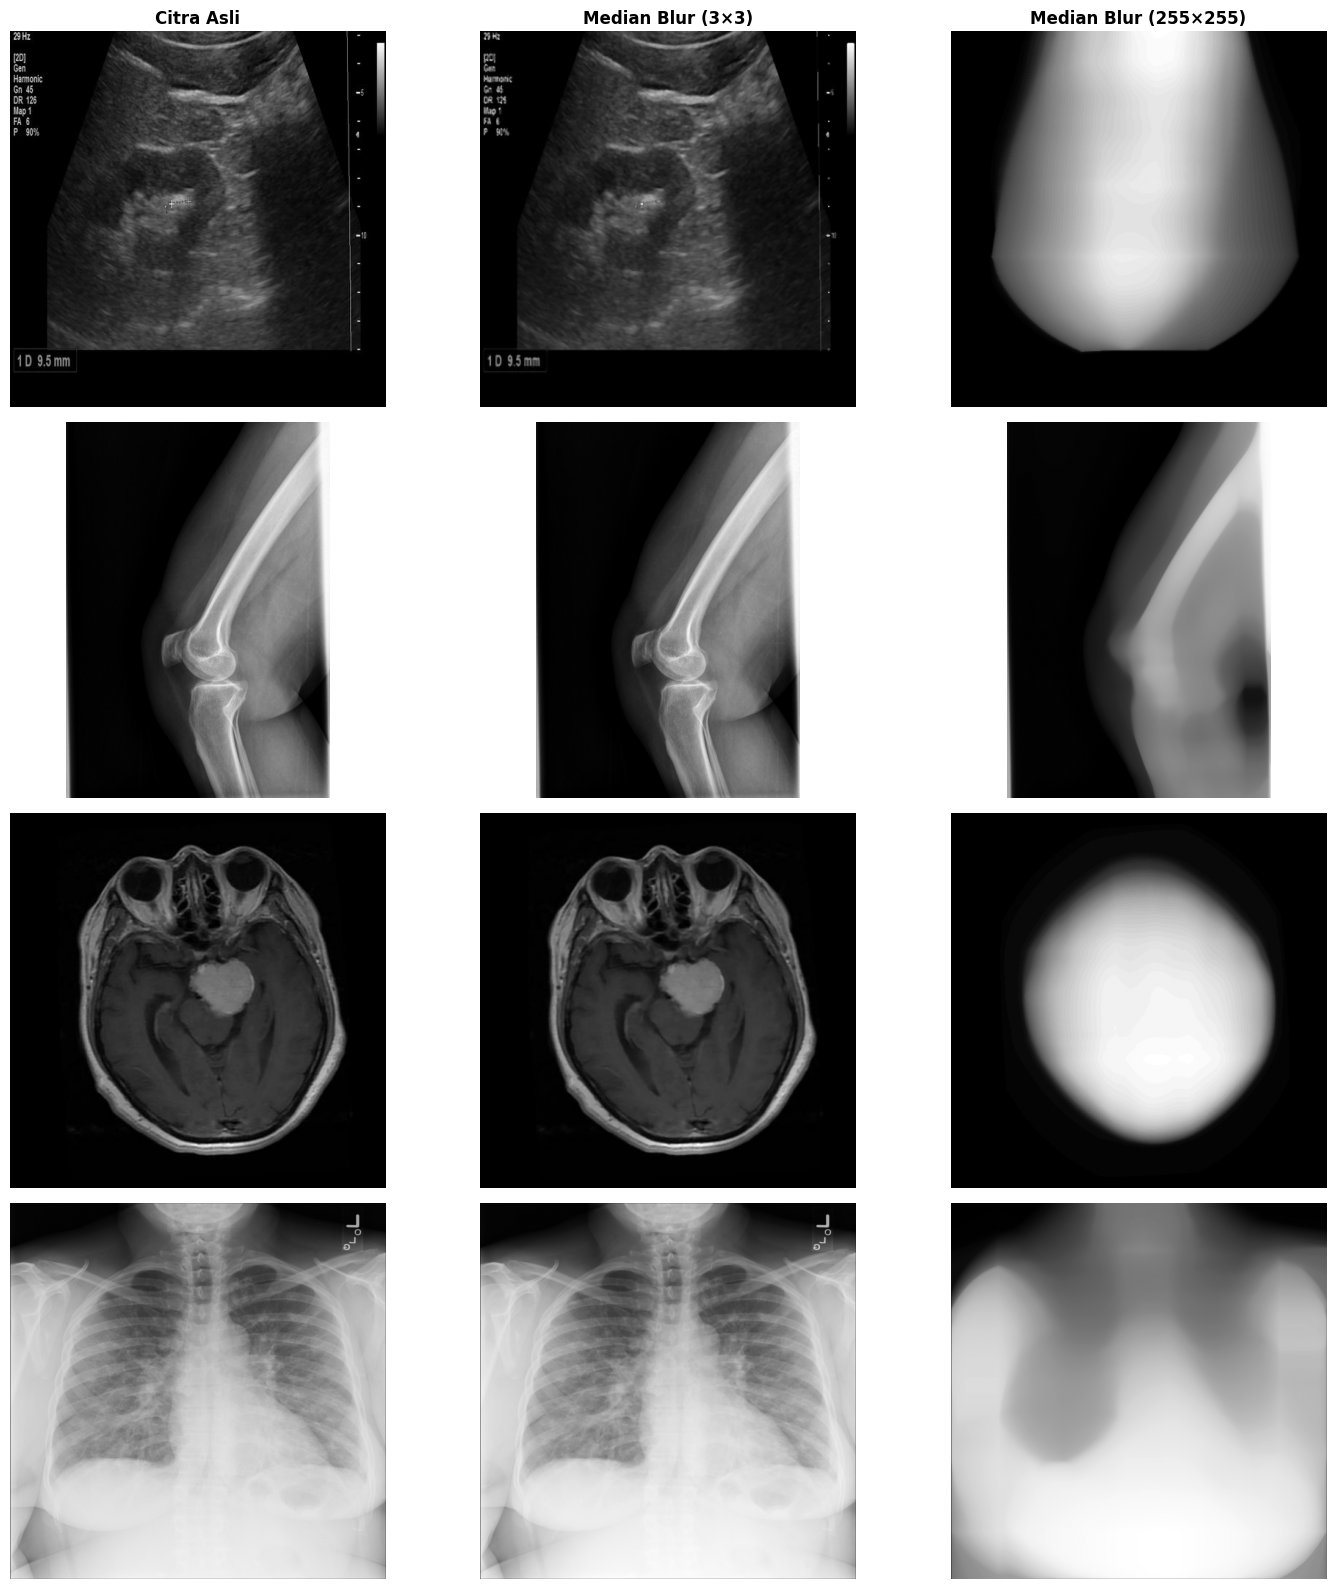

In [4]:
median_min = []
median_max = []

for img in gambar:
    median_min.append(cv2.medianBlur(img, 3))
    median_max.append(cv2.medianBlur(img, 255))
fig, axes = plt.subplots(4, 3, figsize=(15, 16))

nama_proses = [
    'Citra Asli',
    'Median Blur (3×3)',
    'Median Blur (255×255)'
]

for row in range(len(gambar)):
    hasil = [
        gambar[row],
        median_min[row],
        median_max[row]
    ]
    for col in range(3):
        axes[row, col].imshow(hasil[col], cmap='gray')
        axes[row, col].axis('off')
        if row == 0:
            axes[row, col].set_title(
                nama_proses[col],
                fontsize=12,
                fontweight='bold'
            )
    axes[row, 0].set_ylabel(
        judul[row],
        fontsize=12,
        fontweight='bold',
        rotation=90,
        labelpad=15
    )

plt.tight_layout()
plt.show()

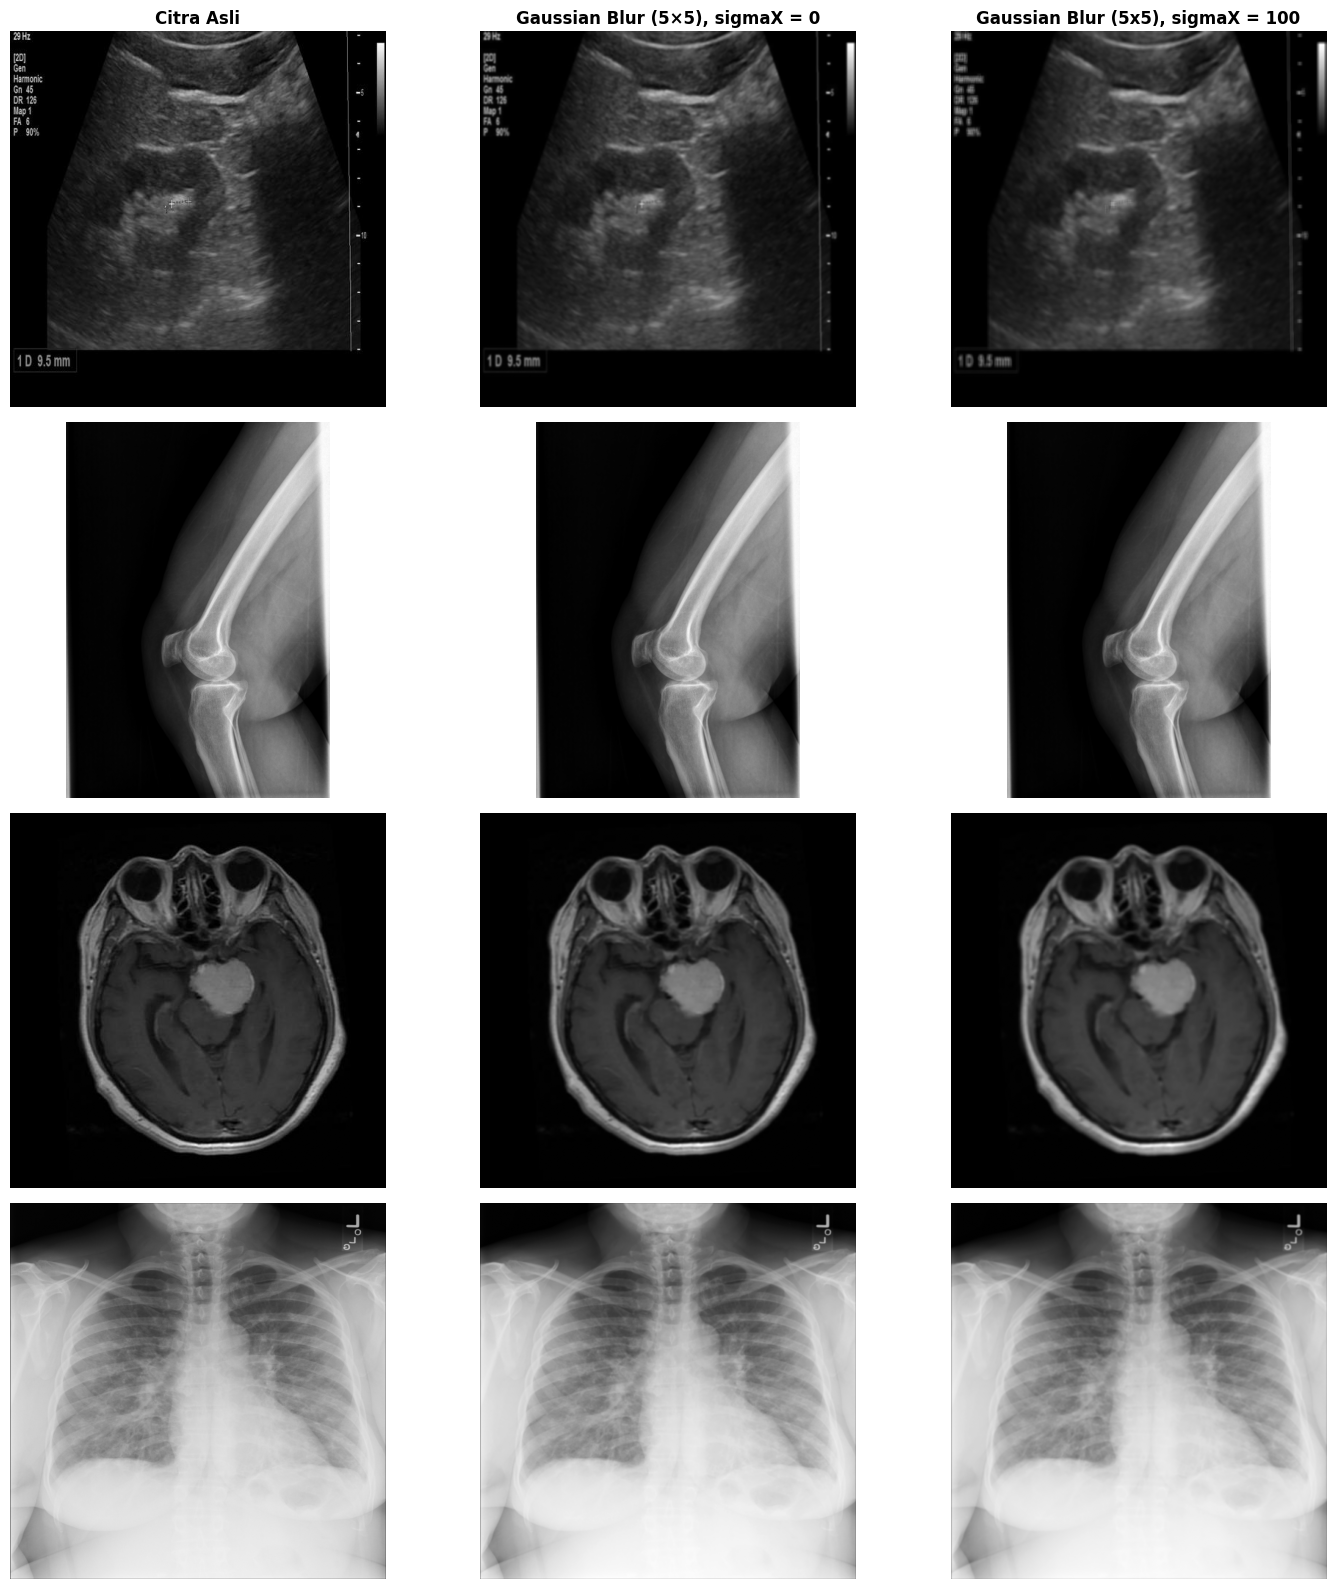

In [5]:
gauss_min = []
gauss_max = []

for img in gambar:
    gauss_min.append(cv2.GaussianBlur(img, (5,5) ,0))
    gauss_max.append(cv2.GaussianBlur(img, (5, 5), 100))
fig, axes = plt.subplots(4, 3, figsize=(15, 16))

nama_proses = [
    'Citra Asli',
    'Gaussian Blur (5×5), sigmaX = 0',
    'Gaussian Blur (5x5), sigmaX = 100'
]

for row in range(len(gambar)):
    hasil = [
        gambar[row],
        gauss_min[row],
        gauss_max[row]
    ]
    for col in range(3):
        axes[row, col].imshow(hasil[col], cmap='gray')
        axes[row, col].axis('off')
        if row == 0:
            axes[row, col].set_title(
                nama_proses[col],
                fontsize=12,
                fontweight='bold'
            )
    axes[row, 0].set_ylabel(
        judul[row],
        fontsize=12,
        fontweight='bold',
        rotation=90,
        labelpad=15
    )

plt.tight_layout()
plt.show()

In [6]:
data_statistik = []

for i in range(len(gambar)):

    data_statistik.append({
        'Citra': judul[i],

        ('Normal', 'Mean'): gambar[i].mean(),

        ('Gaussian Blur min', 'Mean'): gauss_min[i].mean(),
        ('Gaussian Blur max', 'Mean'): gauss_max[i].mean(),

        ('Median Blur min', 'Mean'): median_min[i].mean(),
        ('Median Blur max', 'Mean'): median_max[i].mean(),

        ('Normal', 'Std'): gambar[i].std(),
        
        ('Gaussian Blur min', 'Std'): gauss_min[i].std(),
        ('Gaussian Blur max', 'Std'): gauss_max[i].std(),
        
        ('Median Blur min', 'Std'): median_min[i].std(),
        ('Median Blur max', 'Std'): median_max[i].std()
    })

df_statistik = pd.DataFrame(data_statistik).set_index('Citra')

df_statistik

,"(Normal, Mean)","(Gaussian Blur min, Mean)","(Gaussian Blur max, Mean)","(Median Blur min, Mean)","(Median Blur max, Mean)","(Normal, Std)","(Gaussian Blur min, Std)","(Gaussian Blur max, Std)","(Median Blur min, Std)","(Median Blur max, Std)"
Citra,,,,,,,,,,
Batu Ginjal,31.588848,31.593124,31.598930,31.207893,21.360046,34.089013,32.376577,31.848951,33.009118,20.823152
Osteoarthritis,66.372123,66.371068,66.369064,66.355401,66.011333,69.354624,69.269998,69.248913,69.277540,66.633212
Tumor Otak,27.581001,27.582134,27.580997,27.560066,15.342068,35.863234,35.298461,34.895663,35.698933,20.157708
Chest X-ray,161.096853,161.213571,161.242316,161.074261,156.099635,62.801015,62.512251,62.464764,62.771226,59.928744


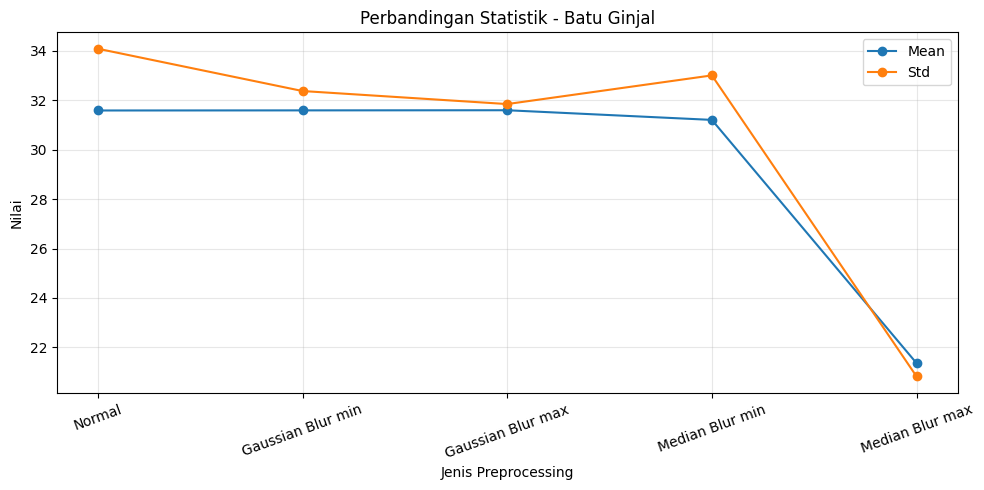

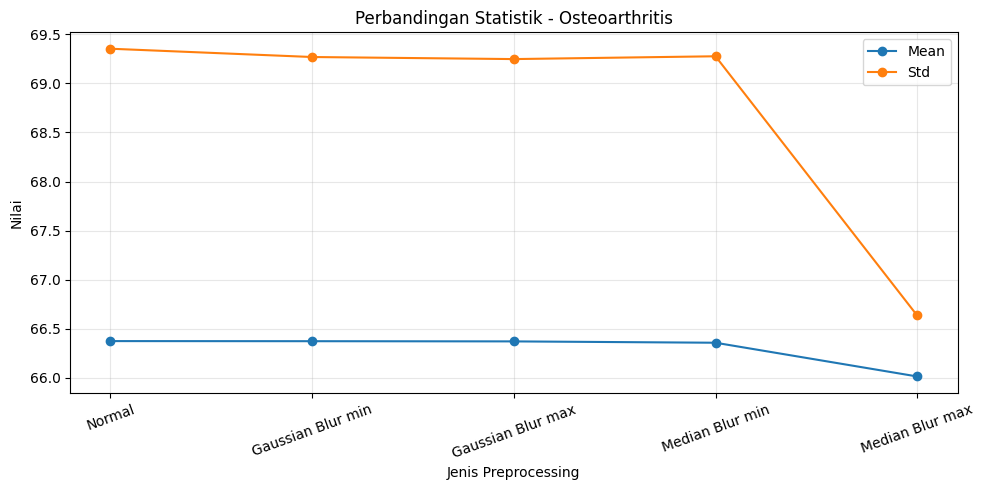

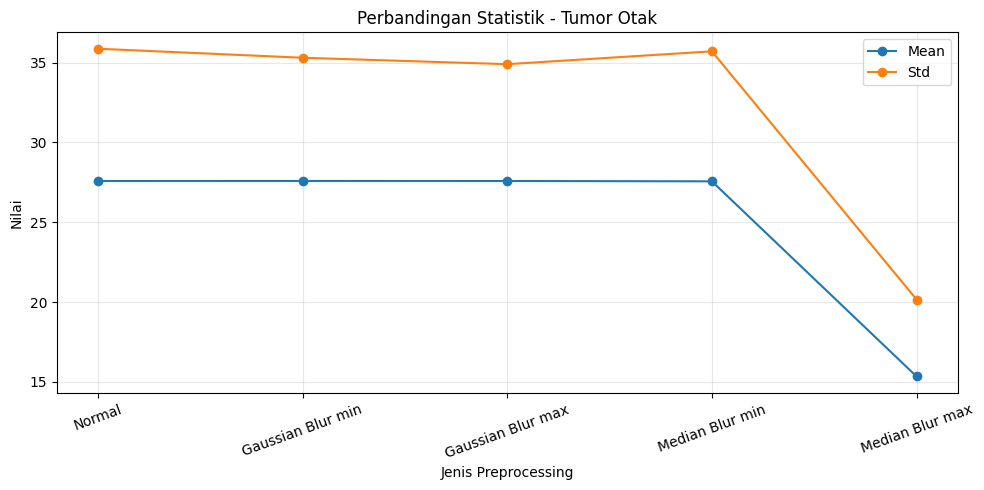

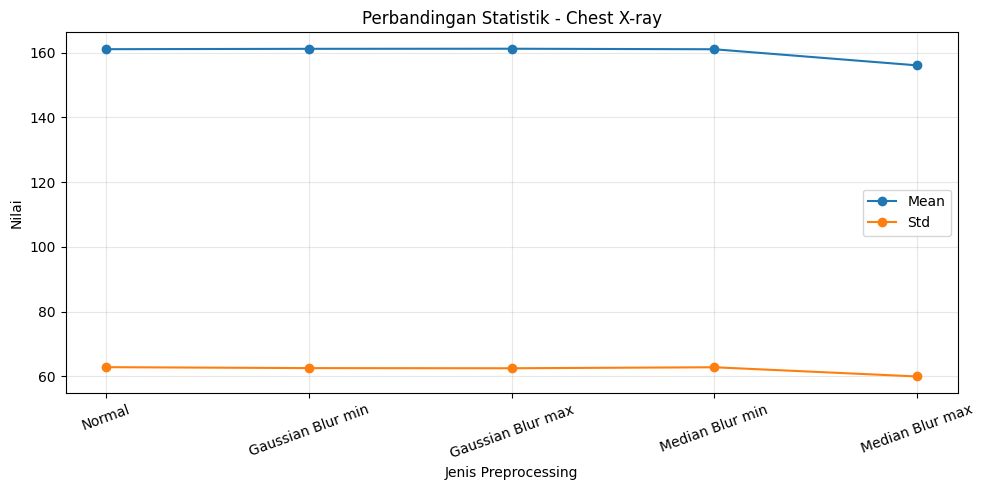

In [7]:
import matplotlib.pyplot as plt

proses = [
    'Normal',
    'Gaussian Blur min',
    'Gaussian Blur max',
    'Median Blur min',
    'Median Blur max'
]

for i in range(len(gambar)):

    # Ambil Mean dari masing-masing hasil preprocessing
    mean = [
        gambar[i].mean(),
        gauss_min[i].mean(),
        gauss_max[i].mean(),
        median_min[i].mean(),
        median_max[i].mean()
    ]

    # Ambil Std dari masing-masing hasil preprocessing
    std = [
        gambar[i].std(),
        gauss_min[i].std(),
        gauss_max[i].std(),
        median_min[i].std(),
        median_max[i].std()
    ]

    # Buat grafik
    plt.figure(figsize=(10, 5))

    plt.plot(proses, mean, marker='o', label='Mean')
    plt.plot(proses, std, marker='o', label='Std')

    plt.title(f'Perbandingan Statistik - {judul[i]}')
    plt.xlabel('Jenis Preprocessing')
    plt.ylabel('Nilai')

    plt.legend()
    plt.grid(True, alpha=0.3)

    plt.xticks(rotation=20)
    plt.tight_layout()
    plt.show()